# Instructions

In this tutorial, we will perform multi-label classification using an ECG-FM model finetuned on the [MIMIC-IV-ECG v1.0 dataset](https://physionet.org/content/mimic-iv-ecg/1.0/). It outlines the data and model loading, as well as inference, same-sample prediction aggregation, and visualizations for embeddings and saliency maps.

ECG-FM was developed in collaboration with the [fairseq_signals](https://github.com/Jwoo5/fairseq-signals) framework, which implements a collection of deep learning methods for ECG analysis.

This is segment the ECG into inputs of 5 s and perform a label-specific aggregation of the predictions from each sample

This document serves largely as a quickstart introduction. Much of this functionality is also available via the [fairseq-signals scripts](https://github.com/bowang-lab/ECG-FM/blob/main/notebooks/infer_cli.ipynb), as well the [ECG-FM scripts](https://github.com/bowang-lab/ECG-FM/tree/main/scripts).

## Installation

Begin by cloning [fairseq_signals](https://github.com/Jwoo5/fairseq-signals) and refer to the installation section in the top-level README. For example, the following commands are sufficient at the present moment:
```
# Creating `fairseq` environment:
conda create --name fairseq python=3.10.6
source activate fairseq
git clone https://github.com/Jwoo5/fairseq-signals
cd fairseq-signals
python3 -m pip install pip==24.0
python3 -m pip install -e .
```

In [1]:
# You may require the following imports depending on what functionality you run
!pip install huggingface-hub
!pip install pandas
!pip install ecg-transform==0.1.3
!pip install umap-learn
!pip install plotly

In [2]:
import os

root = os.path.dirname(os.getcwd())

## Download checkpoints

Checkpoints are available on [HuggingFace](https://huggingface.co/wanglab/ecg-fm). The finetuned model be downloaded using the following command:

In [3]:
import os
from huggingface_hub import hf_hub_download

_ = hf_hub_download(
    repo_id='wanglab/ecg-fm',
    filename='mimic_iv_ecg_finetuned.yaml',
    local_dir=os.path.join(root, 'ckpts'),
)

c:\Users\noors\anaconda3\envs\ecg\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Inference

In [4]:
ckpt_path: str = os.path.join(root, 'ckpts/mimic_iv_ecg_finetuned.pt')
assert os.path.isfile(ckpt_path)

device: str = 'cpu' #changed manually to cpu for local run
batch_size: int = 16
num_workers: int = 0

extract_saliency: bool = True #for computing saliency maps later on

In [5]:
from typing import Any, List

#helper function turning input into python lists
def to_list(obj: Any) -> List[Any]: 
    if isinstance(obj, list):
        return obj

    if isinstance(obj, (np.ndarray, set, dict)):
        return list(obj)

    return [obj]

#getting absolute paths to feed to the model
file_paths = [
    os.path.join(root, 'data/code_15/org', file) for file in \
    os.listdir(os.path.join(root, 'data/code_15/org'))
]
file_paths = to_list(file_paths)
file_paths

['c:\\Users\\noors\\University\\thesis\\ecg-fm\\data/code_15/org\\code_15_1238362.mat',
 'c:\\Users\\noors\\University\\thesis\\ecg-fm\\data/code_15/org\\code_15_1594286.mat',
 'c:\\Users\\noors\\University\\thesis\\ecg-fm\\data/code_15/org\\code_15_2657522.mat',
 'c:\\Users\\noors\\University\\thesis\\ecg-fm\\data/code_15/org\\code_15_270272.mat',
 'c:\\Users\\noors\\University\\thesis\\ecg-fm\\data/code_15/org\\code_15_2754228.mat',
 'c:\\Users\\noors\\University\\thesis\\ecg-fm\\data/code_15/org\\code_15_2969044.mat',
 'c:\\Users\\noors\\University\\thesis\\ecg-fm\\data/code_15/org\\code_15_358121.mat',
 'c:\\Users\\noors\\University\\thesis\\ecg-fm\\data/code_15/org\\code_15_438277.mat',
 'c:\\Users\\noors\\University\\thesis\\ecg-fm\\data/code_15/org\\code_15_795649.mat',
 'c:\\Users\\noors\\University\\thesis\\ecg-fm\\data/code_15/org\\code_15_975093.mat']

## Prepare data

To simplify this tutorial, we have processed a sample of 10 ECGs (14 5s segments) from the [CODE-15% v1.0.0 dataset](https://zenodo.org/records/4916206/) using our [end-to-end data preprocessing pipeline](https://github.com/Jwoo5/fairseq-signals/tree/master/scripts/preprocess/ecg). Its README is also helpful if looking to perform inference using your own dataset, where there are already preprocessing scripts implemented for several public datasets.

In [6]:
from typing import List
from itertools import chain

from scipy.io import loadmat

import numpy as np

import torch
from torch.utils.data import Dataset
from torch.utils.data.dataloader import DataLoader

from ecg_transform.inp import ECGInput, ECGInputSchema
from ecg_transform.sample import ECGMetadata, ECGSample
from ecg_transform.t.base import ECGTransform
from ecg_transform.t.common import (
    HandleConstantLeads,
    LinearResample,
    ReorderLeads,
)
from ecg_transform.t.scale import Standardize
from ecg_transform.t.cut import SegmentNonoverlapping

class ECGFMDataset(Dataset):
    def __init__(
        self,
        schema,
        transforms,
        file_paths,
    ):
        self.schema = schema
        self.transforms = transforms
        self.file_paths = file_paths

    def __len__(self):
        return len(self.file_paths)

    def __getitem__(self, idx):
        mat = loadmat(self.file_paths[idx])
        metadata = ECGMetadata(
            sample_rate=int(mat['org_sample_rate'][0, 0]),
            num_samples=mat['feats'].shape[1],
            lead_names=['I', 'II', 'III', 'aVR', 'aVL', 'aVF', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6'],
            unit=None,
            input_start=0,
            input_end=mat['feats'].shape[1],
        )
        metadata.file = self.file_paths[idx]
        inp = ECGInput(mat['feats'], metadata)
        sample = ECGSample(
            inp,
            self.schema,
            self.transforms,
        )
        source = torch.from_numpy(sample.out).float() #result gets converted to pytorch float tensor

        return source, inp

#flattens all segments from a batch of files into one big tensor, but tracks which original file each segment came from for aggregation later
def collate_fn(inps): 
    sample_ids = list(
        chain.from_iterable([[inp[1]]*inp[0].shape[0] for inp in inps])
    )
    return torch.concatenate([inp[0] for inp in inps]), sample_ids

def file_paths_to_loader(
    file_paths: List[str],
    schema: ECGInputSchema,
    transforms: List[ECGTransform],
    batch_size = 64,
    num_workers = 7,
):
    dataset = ECGFMDataset(
        schema,
        transforms,
        file_paths,
    )

    return DataLoader(
        dataset,
        batch_size=batch_size,
        num_workers=num_workers,
        pin_memory=True,
        sampler=None,
        shuffle=False,
        collate_fn=collate_fn,
        drop_last=False,
    )

In [7]:
import pandas as pd

ECG_FM_LEAD_ORDER = ['I', 'II', 'III', 'aVR', 'aVL', 'aVF', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6']
SAMPLE_RATE = 500
N_SAMPLES = SAMPLE_RATE*5

label_def = pd.read_csv(
    os.path.join(root, 'data/mimic_iv_ecg/labels/label_def.csv'),
     index_col='name',
)
label_names = label_def.index.to_list()
label_names

['Poor data quality',
 'Sinus rhythm',
 'Premature ventricular contraction',
 'Tachycardia',
 'Ventricular tachycardia',
 'Supraventricular tachycardia with aberrancy',
 'Atrial fibrillation',
 'Atrial flutter',
 'Bradycardia',
 'Accessory pathway conduction',
 'Atrioventricular block',
 '1st degree atrioventricular block',
 'Bifascicular block',
 'Right bundle branch block',
 'Left bundle branch block',
 'Infarction',
 'Electronic pacemaker']

In [8]:
AGG_METHODS = {
    'Poor data quality': 'max', #max needs to appear once for classification
    'Sinus rhythm': 'mean', #mean needs to be constantly present
    'Premature ventricular contraction': 'max',
    'Tachycardia': 'mean',
    'Ventricular tachycardia': 'max',
    'Supraventricular tachycardia with aberrancy': 'max',
    'Bradycardia': 'mean',
    'Infarction': 'mean',
    'Atrioventricular block': 'mean',
    'Right bundle branch block': 'mean',
    'Left bundle branch block': 'mean',
    'Electronic pacemaker': 'max',
    'Atrial fibrillation': 'mean',
    'Atrial flutter': 'mean',
    'Accessory pathway conduction': 'mean',
    '1st degree atrioventricular block': 'mean',
    'Bifascicular block': 'mean',
}

ECG_FM_SCHEMA = ECGInputSchema(
    sample_rate=SAMPLE_RATE,
    expected_lead_order=ECG_FM_LEAD_ORDER,
    required_num_samples=N_SAMPLES,
)

ECG_FM_TRANSFORMS = [
    ReorderLeads(
        expected_order=ECG_FM_LEAD_ORDER,
        missing_lead_strategy='raise',
    ), #reordering the leads into the expected order
    LinearResample(desired_sample_rate=SAMPLE_RATE), #resampling to match the expected 500hz
    HandleConstantLeads(strategy='zero'), #zero out broken leads
    Standardize(), #normalise to make data usable over patients
    SegmentNonoverlapping(segment_length=N_SAMPLES),
]

loader = file_paths_to_loader(
    file_paths,
    ECG_FM_SCHEMA,
    ECG_FM_TRANSFORMS,
    batch_size=batch_size,
    num_workers=num_workers,
)

## Load model

In [9]:
from typing import Dict, List, Optional, Tuple, Type, Union
from collections import OrderedDict

import numpy as np
import pandas as pd

import torch

from fairseq_signals.models import build_model_from_checkpoint
from fairseq_signals.models.classification.ecg_transformer_classifier import (
    ECGTransformerClassificationModel
)

In [10]:
#loading model with finetuning 
model: ECGTransformerClassificationModel = build_model_from_checkpoint(
    checkpoint_path=ckpt_path
)

# Forcibly enable the return of attention weights for saliency maps
if extract_saliency:
    model.encoder.encoder.need_weights = extract_saliency
    for layer in model.encoder.encoder.layers:
        layer.need_weights = extract_saliency

model.eval()
model.to(device)

ECGTransformerClassificationModel(
  (encoder): ECGTransformerModel(
    (dropout_input): Dropout(p=0.0, inplace=False)
    (dropout_features): Dropout(p=0.0, inplace=False)
    (encoder): TransformerEncoder(
      (layers): ModuleList(
        (0-11): 12 x TransformerEncoderLayer(
          (self_attn): MultiHeadAttention(
            (dropout): Dropout()
            (k_proj): Linear(in_features=768, out_features=768, bias=True)
            (v_proj): Linear(in_features=768, out_features=768, bias=True)
            (q_proj): Linear(in_features=768, out_features=768, bias=True)
            (out_proj): Linear(in_features=768, out_features=768, bias=True)
          )
          (dropout1): Dropout(p=0.0, inplace=False)
          (dropout2): Dropout(p=0.1, inplace=False)
          (dropout3): Dropout(p=0.0, inplace=False)
          (self_attn_layer_norm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
          (fc1): Linear(in_features=768, out_features=3072, bias=True)
          (f

## Infer

In [11]:
def encoder_out_to_emb(x, device='cpu'):
    # fairseq_signals/models/classification/ecg_transformer_classifier.py
    return torch.div(x.sum(dim=1), (x != 0).sum(dim=1))

def infer(
    model,
    loader,
    device,
    extract_saliency: bool = True,
):
    inps = []
    sources = []
    logits = []
    embs = []
    saliency = []
    file_names = []
    for source, inp in loader:
        source = source.to(device)
        out = model(source=source) 
        inps.extend(inp)
        sources.append(source)
        logits.append(out['out']) #scores per label per segment
        embs.append(encoder_out_to_emb(out['encoder_out'])) #models internal state before classification
        saliency.append(out['saliency']) #attention weights from every layer
        file_names.extend([i.meta.file for i in inp])

    # Handle predictions
    pred = torch.sigmoid(torch.concatenate(logits)).detach().cpu().numpy() #converting to probabilities, sigmoid for multi-class classification
    pred = pd.DataFrame(pred, columns=label_names, index=file_names) #wraps into dataframe with ecg files as rows and labels as columns

    results = {
        'inps': inps,
        'sources': torch.concatenate(sources).detach().cpu().numpy(),
        'embs': torch.concatenate(embs).detach().cpu().numpy(),
        'pred': pred,
    }

    # Handle saliency
    if extract_saliency:
        saliency = torch.concatenate(saliency).detach()
        attn = saliency[:, -1] # Consider only the last attention layer
        results['attn_max'] = attn.max(axis=2).values.squeeze().cpu().detach().numpy() #giving one attention score per time position per segment. High scores = the model found that time region important for prediction

    return results

In [12]:
results = infer(model, loader, device)

c:\Users\noors\anaconda3\envs\ecg\lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


In [13]:
pred = results['pred']
print(f"Number of 5 s segment predictions: {len(pred)}.")
pred

Number of 5 s segment predictions: 14.


,Poor data quality,Sinus rhythm,Premature ventricular contraction,Tachycardia,Ventricular tachycardia,Supraventricular tachycardia with aberrancy,Atrial fibrillation,Atrial flutter,Bradycardia,Accessory pathway conduction,Atrioventricular block,1st degree atrioventricular block,Bifascicular block,Right bundle branch block,Left bundle branch block,Infarction,Electronic pacemaker
c:\Users\noors\University\thesis\ecg-fm\data/code_15/org\code_15_1238362.mat,0.341615,0.447808,0.440088,0.044302,4.599303e-09,0.051420,0.105636,1.246479e-02,0.938258,0.040288,0.010633,0.004005,0.250508,0.166621,0.057196,0.049239,0.141036
c:\Users\noors\University\thesis\ecg-fm\data/code_15/org\code_15_1594286.mat,0.895957,0.988044,0.312560,0.012782,2.730892e-06,0.019095,0.001519,6.983523e-07,0.145045,0.002414,0.001952,0.002770,0.999547,0.999575,0.008619,0.480383,0.061572
c:\Users\noors\University\thesis\ecg-fm\data/code_15/org\code_15_1594286.mat,0.767607,0.990577,0.333246,0.048276,2.038320e-05,0.064786,0.010468,2.039301e-06,0.280763,0.014643,0.001717,0.000707,0.999898,0.999667,0.009258,0.541799,0.044642
c:\Users\noors\University\thesis\ecg-fm\data/code_15/org\code_15_2657522.mat,0.934667,0.457898,0.614614,0.249729,4.488290e-06,0.195991,0.498052,1.261125e-01,0.914458,0.262595,0.182698,0.136559,0.112297,0.205274,0.007075,0.467830,0.467325
c:\Users\noors\University\thesis\ecg-fm\data/code_15/org\code_15_270272.mat,0.783860,0.889992,0.494205,0.025065,6.634911e-05,0.532297,0.101936,3.442787e-04,0.073841,0.056442,0.003199,0.000440,0.645346,0.999317,0.000301,0.179362,0.048376
c:\Users\noors\University\thesis\ecg-fm\data/code_15/org\code_15_270272.mat,0.577706,0.938949,0.475345,0.010826,1.879009e-05,0.218462,0.065241,2.662176e-04,0.161252,0.047494,0.007758,0.001292,0.314572,0.998374,0.000431,0.177881,0.045026
c:\Users\noors\University\thesis\ecg-fm\data/code_15/org\code_15_2754228.mat,0.227541,0.789966,0.317519,0.063679,4.028916e-07,0.025293,0.179121,2.581486e-02,0.143753,0.109025,0.631326,0.601960,0.194222,0.163687,0.347036,0.216403,0.183983
c:\Users\noors\University\thesis\ecg-fm\data/code_15/org\code_15_2969044.mat,0.361556,0.897814,0.269837,0.971841,6.742121e-06,0.081684,0.064310,2.129783e-02,0.119943,0.102913,0.034374,0.020700,0.000233,0.000590,0.048764,0.055010,0.051172
c:\Users\noors\University\thesis\ecg-fm\data/code_15/org\code_15_2969044.mat,0.117802,0.978135,0.344757,0.979856,2.601802e-04,0.102075,0.016660,2.370616e-04,0.047449,0.007546,0.011000,0.005080,0.000031,0.001464,0.016882,0.038244,0.038049
c:\Users\noors\University\thesis\ecg-fm\data/code_15/org\code_15_358121.mat,0.602883,0.869230,0.193926,0.070064,3.628745e-08,0.305229,0.044055,6.595401e-04,0.171293,0.042721,0.006422,0.007250,0.592708,0.980090,0.008776,0.832215,0.228744


# Result handling

## Prediction aggregation

In [14]:
pred_agg = pred.groupby(pred.index).agg(AGG_METHODS).astype(float) #collapses into one prediction per original ecg file
print(f"Number of sample-aggregated predictions: {len(pred_agg)}.")
pred_agg

Number of sample-aggregated predictions: 10.


,Poor data quality,Sinus rhythm,Premature ventricular contraction,Tachycardia,Ventricular tachycardia,Supraventricular tachycardia with aberrancy,Bradycardia,Infarction,Atrioventricular block,Right bundle branch block,Left bundle branch block,Electronic pacemaker,Atrial fibrillation,Atrial flutter,Accessory pathway conduction,1st degree atrioventricular block,Bifascicular block
c:\Users\noors\University\thesis\ecg-fm\data/code_15/org\code_15_1238362.mat,0.341615,0.447808,0.440088,0.044302,4.599303e-09,0.051420,0.938258,0.049239,0.010633,0.166621,0.057196,0.141036,0.105636,0.012465,0.040288,0.004005,0.250508
c:\Users\noors\University\thesis\ecg-fm\data/code_15/org\code_15_1594286.mat,0.895957,0.989311,0.333246,0.030529,2.038320e-05,0.064786,0.212904,0.511091,0.001834,0.999621,0.008939,0.061572,0.005994,0.000001,0.008528,0.001738,0.999722
c:\Users\noors\University\thesis\ecg-fm\data/code_15/org\code_15_2657522.mat,0.934667,0.457898,0.614614,0.249729,4.488290e-06,0.195991,0.914458,0.467830,0.182698,0.205274,0.007075,0.467325,0.498052,0.126112,0.262595,0.136559,0.112297
c:\Users\noors\University\thesis\ecg-fm\data/code_15/org\code_15_270272.mat,0.783860,0.914471,0.494205,0.017946,6.634911e-05,0.532297,0.117546,0.178622,0.005478,0.998845,0.000366,0.048376,0.083588,0.000305,0.051968,0.000866,0.479959
c:\Users\noors\University\thesis\ecg-fm\data/code_15/org\code_15_2754228.mat,0.227541,0.789966,0.317519,0.063679,4.028916e-07,0.025293,0.143753,0.216403,0.631326,0.163687,0.347036,0.183983,0.179121,0.025815,0.109025,0.601960,0.194222
c:\Users\noors\University\thesis\ecg-fm\data/code_15/org\code_15_2969044.mat,0.361556,0.937974,0.344757,0.975848,2.601802e-04,0.102075,0.083696,0.046627,0.022687,0.001027,0.032823,0.051172,0.040485,0.010767,0.055229,0.012890,0.000132
c:\Users\noors\University\thesis\ecg-fm\data/code_15/org\code_15_358121.mat,0.602883,0.869230,0.193926,0.070064,3.628745e-08,0.305229,0.171293,0.832215,0.006422,0.980090,0.008776,0.228744,0.044055,0.000660,0.042721,0.007250,0.592708
c:\Users\noors\University\thesis\ecg-fm\data/code_15/org\code_15_438277.mat,0.973238,0.658348,0.495828,0.028823,8.000776e-11,0.011449,0.954490,0.098629,0.987139,0.003060,0.000805,0.219468,0.053798,0.006362,0.083701,0.968539,0.000455
c:\Users\noors\University\thesis\ecg-fm\data/code_15/org\code_15_795649.mat,0.343211,0.722648,0.449405,0.914644,7.670193e-08,0.296768,0.069917,0.093808,0.089269,0.011971,0.020580,0.182840,0.099272,0.375962,0.151389,0.057957,0.005067
c:\Users\noors\University\thesis\ecg-fm\data/code_15/org\code_15_975093.mat,0.791342,0.455269,0.281627,0.270701,3.023848e-03,0.041443,0.837914,0.301565,0.865906,0.019918,0.013433,0.422232,0.398643,0.505064,0.504270,0.839883,0.009442


## Visualizing embeddings

c:\Users\noors\anaconda3\envs\ecg\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


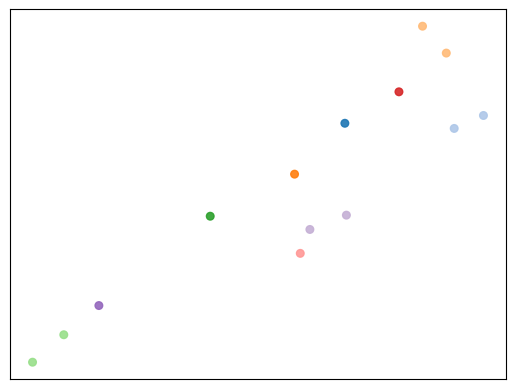

In [15]:
import matplotlib.pyplot as plt
import umap

#map showing ecg segments coloured based on the original file, should be near each other if same diagnosis

reducer = umap.UMAP(n_neighbors=3, min_dist=0.1, n_components=2, random_state=42)
embs_2d = reducer.fit_transform(results['embs'])

# Generate a color map
sample_identifier = pred.index.to_series()
unique_values = sample_identifier.unique()
colors = plt.colormaps.get_cmap('tab20')  # Use a colormap with enough distinct colors
color_map = {val: colors(i) for i, val in enumerate(unique_values)}
colored_items = sample_identifier.map(color_map)

# Plot the 2D UMAP visualization
plt.scatter(
    embs_2d[:, 0],
    embs_2d[:, 1],
    s=30,
    alpha=0.9,
    color=colored_items.values,
    rasterized=True,
)

# Remove axis labels and grid
plt.xticks([])
plt.yticks([])
plt.grid(False)

More fitting when visualizing many embeddings:
```
import matplotlib.pyplot as plt
import umap
reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, n_components=2, random_state=42) # Better when there are more embeddings

# Plot the 2D UMAP visualization
plt.scatter(
    embs_2d[:, 0],
    embs_2d[:, 1],
    s=1,
    alpha=0.9,
    rasterized=True,
)

# Remove axis labels and grid
plt.xticks([])
plt.yticks([])
plt.grid(False)
```

## Saliency maps

for interpretability, where is the model looking?

In [16]:
from typing import Tuple

import numpy as np

from scipy.ndimage import map_coordinates

import matplotlib.pyplot as plt
import plotly.graph_objects as go

In [17]:
sample_idx = 0

saliency_lead = 'II'
lead_ind = ECG_FM_LEAD_ORDER.index(saliency_lead)

In [18]:
signal = results['sources'][sample_idx, lead_ind]
attn_max = results['attn_max'][sample_idx]

In [19]:
def blend_colors_hex(start_color: str, end_color: str, activations: np.ndarray) -> np.ndarray:
    """
    Blends between two colors based on an array of blend factors.

    Parameters
    ----------
    start_color : str
        Hexadecimal color code for the start color.
    end_color : str
        Hexadecimal color code for the end color.
    activations : np.ndarray
        An array of blend factors where 0 corresponds to the start color and 1 to the end color.

    Returns
    -------
    np.ndarray
        An array of hexadecimal color codes resulting from the blends.

    Raises
    ------
    ValueError
        If any of the input blend factors are not within the range [0, 1].
    """
    if np.any((activations < 0) | (activations > 1)):
        raise ValueError("All blend factors must be between 0 and 1.")

    # Convert hexadecimal to RGB
    def hex_to_rgb(hex_color: str) -> Tuple[int]:
        return tuple(int(hex_color[i: i+2], 16) for i in (1, 3, 5))

    # Get RGB tuples
    start_rgb = np.array(hex_to_rgb(start_color))
    end_rgb = np.array(hex_to_rgb(end_color))

    # Blend RGB values
    blended_rgb = np.outer(1 - activations, start_rgb) + np.outer(activations, end_rgb)

    # Convert blended RGB back to hex codes
    return blended_rgb / 255

def colored_line_segments(data: np.ndarray, colors: np.ndarray, ax=None, **kwargs):
    """
    Plots line segments based on the provided data points, with each segment
    colored according to the corresponding color specification in `colors`.

    Parameters
    ----------
    data : np.ndarray
        Array of y-values for the line segments.
    colors : np.ndarray
        Array of colors, each color applied to the corresponding line segment
        between points i and i+1.

    Raises
    ------
    ValueError
        If the `colors` array does not have exactly one less element than the `data` array,
        as each segment needs a unique color.

    Returns
    -------
    None
    """
    if len(colors) != len(data) - 1:
        raise ValueError("Colors array must have one fewer elements than data array.")

    if ax is None:
        for i in range(len(data) - 1):
            plt.plot([i, i + 1], [data[i], data[i + 1]], color=colors[i], **kwargs)
    else:
        for i in range(len(data) - 1):
            ax.plot([i, i + 1], [data[i], data[i + 1]], color=colors[i], **kwargs)

def prep_saliency_values(attn_max, target_sample_length):
    # Resample to original sample size
    new_dims = [
        np.linspace(0, original_length-1, new_length) \
        for original_length, new_length in \
        zip(attn_max.shape, (target_sample_length - 1,))
    ]
    coords = np.meshgrid(*new_dims, indexing='ij')
    attn_max = map_coordinates(attn_max, coords)

    # Min-max normalization
    attn_max = attn_max - attn_max.min()
    attn_max = attn_max/attn_max.max()

    return attn_max

saliency_prepped = prep_saliency_values(
    attn_max.ravel(),
    attn_max.shape[0] * signal.shape[-1],
)
saliency_colors = blend_colors_hex('#0047AB', '#DC143C', saliency_prepped)
saliency_colors = (saliency_colors*255).astype(int)

# Define a custom colorscale from blue to red
colorscale = [[0, 'blue'], [1, 'red']]  # Simple gradient from blue to red

time = np.arange(2500)

# Create the figure
fig = go.Figure()
y_values = signal[:-1]
for i in range(len(y_values) - 1):
    fig.add_trace(
        go.Scatter(
            x=[time[i], time[i + 1]],
            y=[y_values[i], y_values[i + 1]],
            mode='lines',
            line=dict(color='rgb({},{},{})'.format(*saliency_colors[i]), width=2),
            showlegend=False  # Avoid cluttering the legend
        )
    )
fig['layout']['yaxis'].update(autorange = True)
fig['layout']['xaxis'].update(autorange = True)

fig.show()